<div style="
    background-color:#2c3e50; 
    color:#ecf0f1; 
    font-weight:bold; 
    padding:20px 30px; 
    font-size:20px; 
    border-radius:8px; 
    text-align:center;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    letter-spacing: 0.5px;
">
    Generates labels for laboraotry washing machine experiments
</div>

<h3 style="
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    color:#D4495e;
    margin-top:15px;
    font-weight:600;
">
    Generates label for: <br>
    Water inlet and outlet <br>
    Water heating
</h3>

In [ ]:
import numpy as np
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt


# Load aggregated data
aggregated = pd.read_csv("aggregated_data.csv")

# Filter your master table first
laboratory = aggregated[
    (aggregated['environment'] == 'laboratory') &
    (aggregated['type'] == 'wm') # wm = washing machine
]

<h3 style="
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    color:#D4495e;
    margin-top:15px;
    font-weight:600;
">
Rule based labeling for water inlet and outlet
</h3>

Demo plot for file: ./laboratory/washing_machine/becken_BWM5379IX/cotton/wm_becken_BWM5379IX_cold_cotton_0_0.csv, index: 29, program_heat: 0


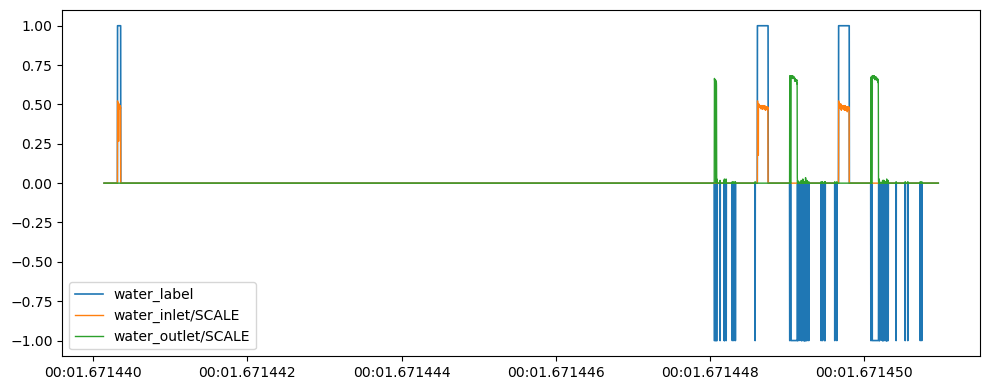

Done


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Config ---------------------------------------------------------------
THRESHOLD = 0.0       
SCALE = 340.0        # plot scaling used for demo only
UPDATE = False
DEMO = True

# Label mapping:
# 0: both == 0
# 1: inlet > 0,  outlet == 0
# -1: inlet == 0, outlet > 0
# 2: both > 0
VALUES = [0, 1, -1, 2]

# --- Loop ---------------------------------------------------------------
for idx, row in laboratory.iterrows():
    file_path = row.file_path
    program_heat = getattr(row, "program_heat", None)

    try:
        df = pd.read_csv(
            file_path,
            usecols=["timestamp", "water_inlet", "water_outlet"],
            low_memory=False
        )
    except Exception as e:
        print(f"⚠️  Could not read {file_path}: {e}")
        continue


    df["water_inlet"] = pd.to_numeric(df["water_inlet"], errors="coerce").fillna(0.0)
    df["water_outlet"] = pd.to_numeric(df["water_outlet"], errors="coerce").fillna(0.0)

 
    inlet_pos  = df["water_inlet"]  > THRESHOLD
    outlet_pos = df["water_outlet"] > THRESHOLD

    conditions = [
        (~inlet_pos) & (~outlet_pos),  # both 0
        ( inlet_pos) & (~outlet_pos),  # inlet > 0, outlet = 0
        (~inlet_pos) & ( outlet_pos),  # inlet = 0, outlet > 0
        ( inlet_pos) & ( outlet_pos),  # both > 0
    ]

    df["water_label"] = np.select(conditions, VALUES, default=np.nan).astype("float32")

    if DEMO:
        print(f"Demo plot for file: {file_path}, index: {idx}, program_heat: {program_heat}")

        ts = pd.to_datetime(df["timestamp"], errors="coerce")
        plt.figure(figsize=(10, 4))
        plt.plot(ts, df["water_label"], label="water_label", linewidth=1.2)
        plt.plot(ts, df["water_inlet"] / SCALE, label="water_inlet/SCALE", linewidth=1.0)
        plt.plot(ts, df["water_outlet"] / SCALE, label="water_outlet/SCALE", linewidth=1.0)
        plt.legend()
        plt.tight_layout()
        plt.show()
        break  # only demo first file

    if UPDATE:
        try:
            full_df = pd.read_csv(file_path, low_memory=False)
            full_df["water_label"] = df["water_label"]
            full_df.to_csv(file_path, index=False)
        except Exception as e:
            print(f"⚠️  Could not update {file_path}: {e}")

print("Done")

<h3 style="
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    color:#D4495e;
    margin-top:15px;
    font-weight:600;
">
Rule based water heating label
</h3>

Demo plot for file: ./laboratory/washing_machine/becken_BWM5379IX/cotton/wm_becken_BWM5379IX_cold_cotton_40_0.csv, index: 49, program_heat: 40


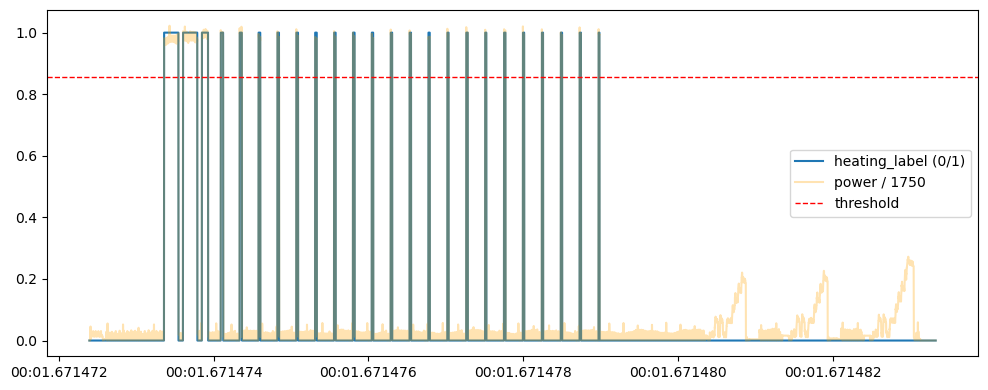

Done


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Config ---
THRESHOLD = 1500
UPDATE = False
DEMO = True

for row in laboratory.itertuples(index=True):
    idx = row.Index
    file_path = row.file_path

    # skip demo for <40 °C programs
    if DEMO and int(getattr(row, "program_heat", 0) or 0) < 40:
        continue

    try:
        df = pd.read_csv(file_path, usecols=["timestamp", "power"], low_memory=False)
    except Exception as e:
        print(f"⚠️ Could not read {file_path}: {e}")
        continue

    # simple threshold → 0/1 label
    df["heating_label"] = (pd.to_numeric(df["power"], errors="coerce").fillna(0) >= THRESHOLD).astype(int)

    if DEMO:
        print(f"Demo plot for file: {file_path}, index: {idx}, program_heat: {getattr(row, 'program_heat', 'NA')}")
        ts = pd.to_datetime(df["timestamp"], errors="coerce")

        plt.figure(figsize=(10, 4))
        plt.plot(ts, df["heating_label"], label="heating_label (0/1)")
        plt.plot(ts, df["power"] / 1750, color="orange", alpha=0.3, label="power / 1750")
        plt.axhline(THRESHOLD / 1750, linestyle="--", color="red", linewidth=1, label="threshold")
        plt.legend()
        plt.tight_layout()
        plt.show()
        break  # show just one demo

    if UPDATE:
        # overwrite original CSV with label added
        full_df = pd.read_csv(file_path, low_memory=False)
        full_df["heating_label"] = df["heating_label"]
        full_df.to_csv(file_path, index=False)

print("Done")